In [ ]:
# Reproducible data loading
# Use breast_cancer.csv when it is available; otherwise rebuild the same
# Wisconsin diagnostic dataset from scikit-learn so "Run all" works cleanly.
from pathlib import Path
import numpy as np
import pandas as pd

def load_project_data():
    candidates = [
        Path("breast_cancer.csv"),
        Path("/content/breast_cancer.csv"),
        Path("/mnt/data/breast_cancer.csv"),
    ]
    for path in candidates:
        if path.exists():
            data = pd.read_csv(path)
            data.columns = data.columns.str.strip()
            if {"id", "diagnosis"}.issubset(data.columns):
                print(f"Loaded: {path}")
                return data

    from sklearn.datasets import load_breast_cancer
    raw = load_breast_cancer(as_frame=True)
    features = raw.data.copy()

    def project_name(name):
        if name.startswith("mean "):
            return name[5:].replace(" ", "_") + "_mean"
        if name.endswith(" error"):
            return name[:-6].replace(" ", "_") + "_se"
        if name.startswith("worst "):
            return name[6:].replace(" ", "_") + "_worst"
        return name.replace(" ", "_")

    features.columns = [project_name(c) for c in features.columns]
    data = features.copy()
    data.insert(0, "id", np.arange(1, len(data) + 1))
    data.insert(1, "diagnosis", np.where(raw.target.to_numpy() == 0, "M", "B"))
    print("breast_cancer.csv not found; loaded the equivalent scikit-learn dataset.")
    return data

df = load_project_data()
print("Dataset shape:", df.shape)


In [ ]:
df.head()


LOGISTIC REGRESSION

In [3]:
# IMPORT PACKAGES
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    f1_score
)

# Folders to save tables and figures
os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

print("Packages loaded")

Packages loaded


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["id", "diagnosis"])
y = df["diagnosis"].map({"B": 0, "M": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

train = X_train.copy()
train["target"] = y_train
test = X_test.copy()
test["target"] = y_test

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()


In [5]:
# OUR TARGET
print("Training data:")
print(train["target"].value_counts())

print("\nTest data:")
print(test["target"].value_counts())

print("\n0 = Benign")
print("1 = Malignant")

Training data:
target
0    285
1    170
Name: count, dtype: int64

Test data:
target
0    72
1    42
Name: count, dtype: int64

0 = Benign
1 = Malignant


In [6]:
# SEPARATE FEATURES AND TARGETS
# X = the 30 measurements
# y = diagnosis

X_train = train.drop(columns=["target"])
y_train = train["target"]

X_test = test.drop(columns=["target"])
y_test = test["target"]

print("Training features:", X_train.shape)
print("Test features:", X_test.shape)

print("Number of variables:", X_train.shape[1])

Training features: (455, 30)
Test features: (114, 30)
Number of variables: 30


In [7]:
# STANDARIZATION
scaler = StandardScaler()

# MEAN AND SD from TRAINING DATA
X_train_scaled = scaler.fit_transform(X_train)

# MEAN AND SD FROM TEST DATA
X_test_scaled = scaler.transform(X_test)

print("Data standardized")

Data standardized


In [8]:
# TRAIN THE REGRESSION MODEL
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Model trained")

Model trained


In [9]:
# MAKE PREDICTIONS
# Final predicted class: 0 or 1
y_pred = model.predict(X_test_scaled)

# Probability of malignancy
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Predictions completed")

print("\nFirst 10 predicted classes:")
print(y_pred[:10])

print("\nFirst 10 malignant probabilities:")
print(y_prob[:10])

Predictions completed

First 10 predicted classes:
[0 1 0 1 1 0 1 0 0 0]

First 10 malignant probabilities:
[3.64568116e-04 9.99999989e-01 4.25679471e-02 5.76187322e-01
 5.09155489e-01 6.16001620e-04 7.61534086e-01 1.01217174e-03
 5.68725516e-04 1.07675795e-02]


In [10]:
# MEASURE MODEL METRICS
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

# Sensitivity
sensitivity = tp / (tp + fn)

# Specificity
specificity = tn / (tn + fp)

# F1 score
f1 = f1_score(y_test, y_pred)

# ROC-AUC
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", round(auc, 3))
print("Sensitivity:", round(sensitivity, 3))
print("Specificity:", round(specificity, 3))
print("F1:", round(f1, 3))

ROC-AUC: 0.996
Sensitivity: 0.929
Specificity: 0.986
F1: 0.951


In [11]:
# SAVE RESULTS
logistic_results = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "Sensitivity",
        "Specificity",
        "F1"
    ],
    "Value": [
        auc,
        sensitivity,
        specificity,
        f1
    ]
})

logistic_results.to_csv(
    "results/logistic_metrics.csv",
    index=False
)

logistic_results

,Metric,Value
0,ROC-AUC,0.996032
1,Sensitivity,0.928571
2,Specificity,0.986111
3,F1,0.951220


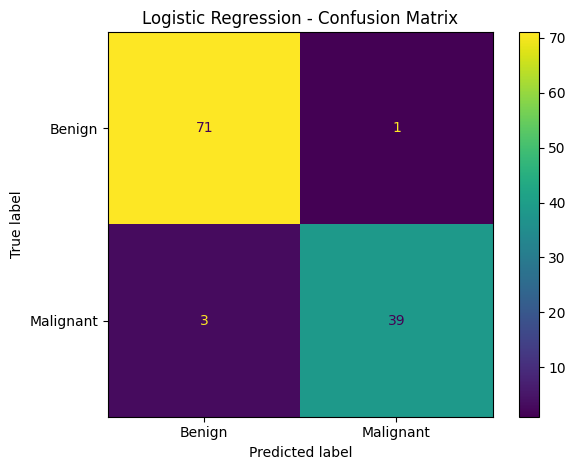

In [12]:
# BUILD CONFUSION MATRIX
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "figures/logistic_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

71 BENIGN = TRUE, 39 MALIGNANT = TURE

1 MALIGNANT WRONG, 3 BENIGN = WRONG

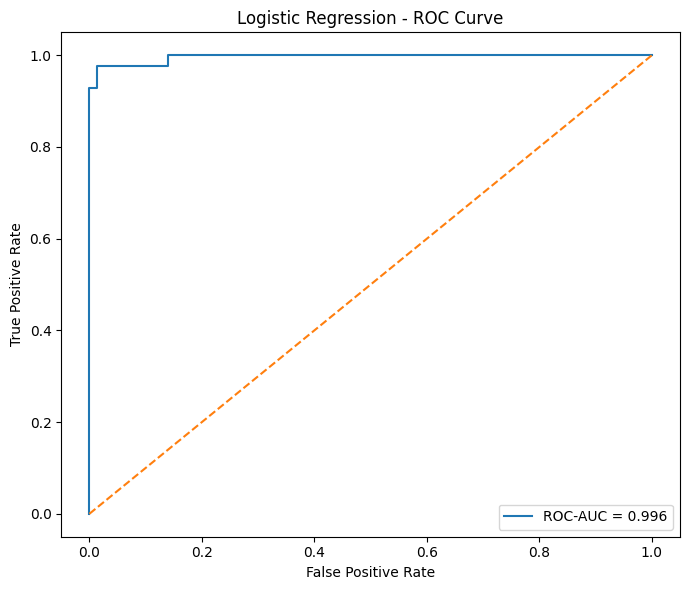

In [13]:
# ROC CURVE
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {auc:.3f}"
)

# Reference line for random classification
plt.plot(
    [0, 1],
    [0, 1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Logistic Regression - ROC Curve")

plt.legend()

plt.tight_layout()

plt.savefig(
    "figures/logistic_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
# MODEL FEATURES
feature_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

# Absolute coefficient = strength of contribution
feature_table["Importance"] = abs(
    feature_table["Coefficient"]
)

feature_table = feature_table.sort_values(
    "Importance",
    ascending=False
)

top_features = feature_table.head(10)

top_features

,Feature,Coefficient,Importance
21,texture_worst,1.434093,1.434093
10,radius_se,1.233325,1.233325
28,symmetry_worst,1.061264,1.061264
7,concave_points_mean,0.952813,0.952813
26,concavity_worst,0.911406,0.911406
13,area_se,0.909029,0.909029
15,compactness_se,-0.906925,0.906925
23,area_worst,0.900477,0.900477
20,radius_worst,0.896968,0.896968
6,concavity_mean,0.782298,0.782298


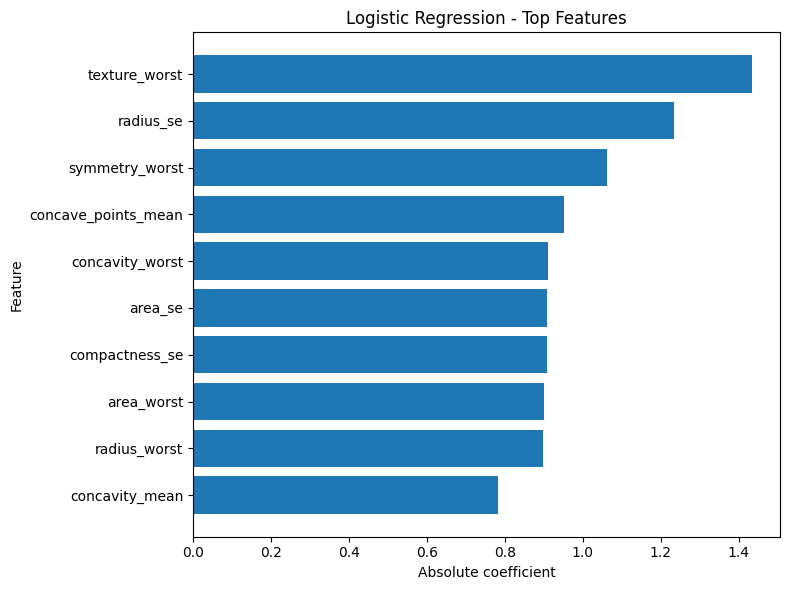

In [16]:
# TOP FEATURES
top_features.to_csv(
    "results/logistic_top_features.csv",
    index=False
)

plot_data = top_features.sort_values(
    "Importance"
)

plt.figure(figsize=(8, 6))

plt.barh(
    plot_data["Feature"],
    plot_data["Importance"]
)

plt.xlabel("Absolute coefficient")
plt.ylabel("Feature")

plt.title("Logistic Regression - Top Features")

plt.tight_layout()

plt.savefig(
    "figures/logistic_top_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# K-MEANS

In [17]:
# PREPARE K-MEANS DATA

true_diagnosis = df["diagnosis"].map({
    "B": 0,
    "M": 1
})

# Remove ID and diagnosis

X_kmeans = df.drop(
    columns=["id", "diagnosis"]
)

print("K-means data shape:", X_kmeans.shape)

X_kmeans.head()

K-means data shape: (569, 30)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [18]:
# STANDARIZE
k_scaler = StandardScaler()

X_kmeans_scaled = k_scaler.fit_transform(
    X_kmeans
)

print("K-means data standardized")

K-means data standardized


In [19]:
# DETERMINE THE K
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 7)

silhouette_values = []

for k in k_values:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = km.fit_predict(
        X_kmeans_scaled
    )

    score = silhouette_score(
        X_kmeans_scaled,
        labels
    )

    silhouette_values.append(score)

    print(
        "k =",
        k,
        "| Silhouette =",
        round(score, 3)
    )

k = 2 | Silhouette = 0.345
k = 3 | Silhouette = 0.314
k = 4 | Silhouette = 0.28
k = 5 | Silhouette = 0.159
k = 6 | Silhouette = 0.16


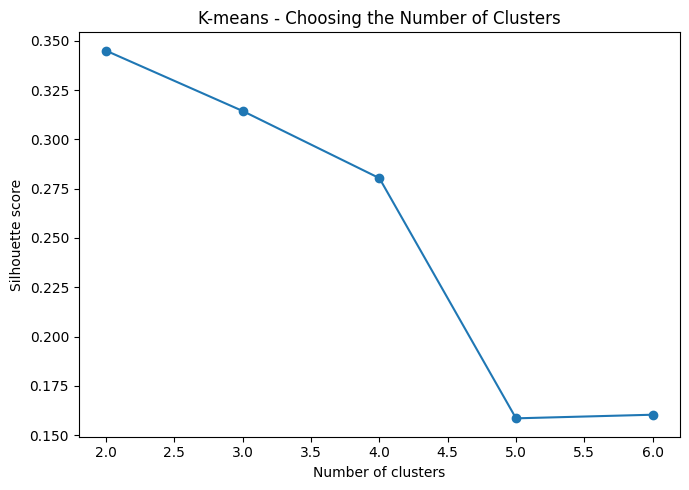

In [20]:
# SILHOUETTE PLOT
plt.figure(figsize=(7, 5))

plt.plot(
    list(k_values),
    silhouette_values,
    marker="o"
)

plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")

plt.title("K-means - Choosing the Number of Clusters")

plt.tight_layout()

plt.savefig(
    "figures/kmeans_silhouette.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
# FINAL K-MEANS
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(
    X_kmeans_scaled
)

print("K-means completed")

print("\nCluster sizes:")
print(pd.Series(clusters).value_counts())

K-means completed

Cluster sizes:
1    380
0    189
Name: count, dtype: int64


In [22]:
# MEASURE METRICS
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score
)

ari = adjusted_rand_score(
    true_diagnosis,
    clusters
)

nmi = normalized_mutual_info_score(
    true_diagnosis,
    clusters
)

silhouette = silhouette_score(
    X_kmeans_scaled,
    clusters
)

print("ARI:", round(ari, 3))
print("NMI:", round(nmi, 3))
print("Silhouette:", round(silhouette, 3))

ARI: 0.671
NMI: 0.555
Silhouette: 0.345


In [23]:
# SAVE RESULTS
kmeans_results = pd.DataFrame({
    "Metric": [
        "ARI",
        "NMI",
        "Silhouette"
    ],
    "Value": [
        ari,
        nmi,
        silhouette
    ]
})

kmeans_results.to_csv(
    "results/kmeans_metrics.csv",
    index=False
)

kmeans_results

,Metric,Value
0,ARI,0.670721
1,NMI,0.554612
2,Silhouette,0.344974


In [24]:
# CLUSTER VS. DIAGNOSIS
comparison = pd.crosstab(
    df["diagnosis"],
    clusters,
    rownames=["Diagnosis"],
    colnames=["Cluster"]
)

comparison

Cluster,0,1
Diagnosis,,
B,14,343
M,175,37


In [26]:
# PCA
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_kmeans_scaled
)

pc1 = pca.explained_variance_ratio_[0] * 100
pc2 = pca.explained_variance_ratio_[1] * 100

print("PC1 variance:", round(pc1, 1), "%")
print("PC2 variance:", round(pc2, 1), "%")
print(
    "Total:",
    round(pc1 + pc2, 1),
    "%"
)

PC1 variance: 44.3 %
PC2 variance: 19.0 %
Total: 63.2 %


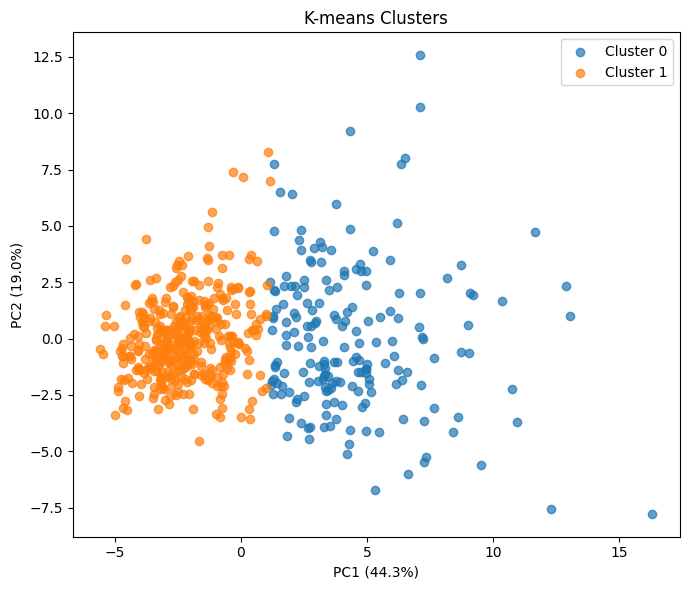

In [27]:
# PCA: K-MEANS CLUSTERS
plt.figure(figsize=(7, 6))

for cluster in [0, 1]:

    plt.scatter(
        X_pca[clusters == cluster, 0],
        X_pca[clusters == cluster, 1],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.xlabel(
    f"PC1 ({pc1:.1f}%)"
)

plt.ylabel(
    f"PC2 ({pc2:.1f}%)"
)

plt.title("K-means Clusters")

plt.legend()

plt.tight_layout()

plt.savefig(
    "figures/kmeans_pca_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

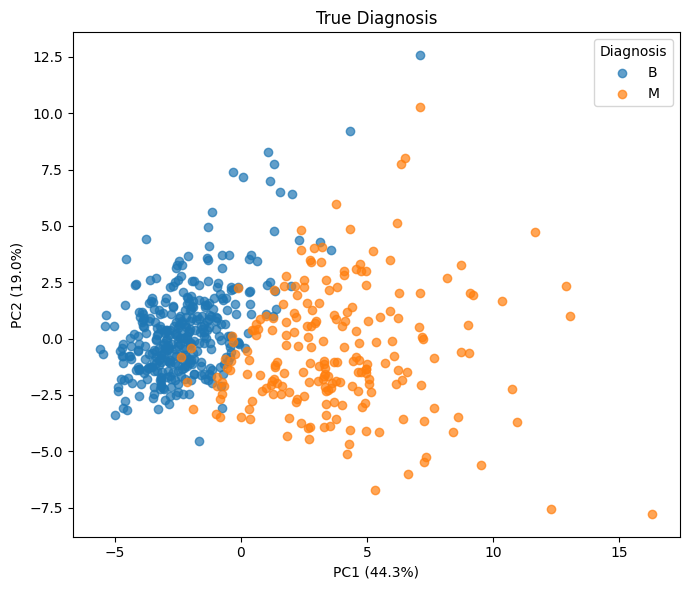

In [28]:
# PCA: DIAGNOSIS
plt.figure(figsize=(7, 6))

diagnosis = df["diagnosis"]

for label in ["B", "M"]:

    plt.scatter(
        X_pca[diagnosis == label, 0],
        X_pca[diagnosis == label, 1],
        label=label,
        alpha=0.7
    )

plt.xlabel(
    f"PC1 ({pc1:.1f}%)"
)

plt.ylabel(
    f"PC2 ({pc2:.1f}%)"
)

plt.title("True Diagnosis")

plt.legend(
    title="Diagnosis"
)

plt.tight_layout()

plt.savefig(
    "figures/kmeans_pca_diagnosis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
# SAVE DATA
cluster_data = pd.DataFrame({
    "id": df["id"],
    "diagnosis": df["diagnosis"],
    "cluster": clusters,
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1]
})

cluster_data.to_csv(
    "results/kmeans_patient_results.csv",
    index=False
)

cluster_data.head()

,id,diagnosis,cluster,PC1,PC2
0,842302,M,0,9.192837,1.948583
1,842517,M,0,2.387802,-3.768172
2,84300903,M,0,5.733896,-1.075174
3,84348301,M,0,7.122953,10.275589
4,84358402,M,0,3.935302,-1.948072


In [31]:
# SUMMARY
print("LOGISTIC REGRESSION")
print("ROC-AUC:", round(auc, 3))
print("Sensitivity:", round(sensitivity, 3))
print("Specificity:", round(specificity, 3))
print("F1:", round(f1, 3))

print("\nK-MEANS")
print("ARI:", round(ari, 3))
print("NMI:", round(nmi, 3))
print("Silhouette:", round(silhouette, 3))

LOGISTIC REGRESSION
ROC-AUC: 0.996
Sensitivity: 0.929
Specificity: 0.986
F1: 0.951

K-MEANS
ARI: 0.671
NMI: 0.555
Silhouette: 0.345


In [ ]:
# Package the generated tables and figures.
import shutil
shutil.make_archive("breast_cancer_results", "zip", root_dir=".", base_dir="results")
print("Created breast_cancer_results.zip")
